# Capítulo 1 – Análisis Exploratorio de Datos (EDA)
## Sistema de Bicicletas Compartidas – Dataset `hour.csv`

En este capítulo realizamos un análisis exploratorio inicial del conjunto de datos
horario del sistema de bicicletas compartidas. El objetivo es entender la estructura
de los datos, las variables disponibles y sus relaciones básicas con la demanda
de bicicletas (`cnt`).

Este notebook está diseñado para formar parte del libro Jupyter-Book del proyecto
de regresión lineal múltiple avanzada.


## 1. Carga de librerías y datos

Primero importamos las librerías necesarias y cargamos el archivo `hour.csv` 
desde la carpeta `data/` ubicada en el directorio raíz del proyecto.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


In [3]:
# Ruta relativa al archivo de datos desde la carpeta 'book'
data_path = "../data/hour.csv"

df = pd.read_csv(data_path)

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### 1.1. Estructura general del dataset

Revisamos el número de observaciones, variables y tipos de datos para tener una
primera idea de la información disponible.


In [4]:
df.shape

(17379, 17)

In [5]:
df.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [6]:
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### 1.2. Conversión de variables categóricas

Algunas variables son códigos enteros que representan categorías (por ejemplo,
estación, mes, hora, tipo de día, condiciones climáticas, etc.). Las convertimos
al tipo `category` para facilitar su manejo en análisis posteriores.


In [7]:
categorical_cols = [
    "season", "yr", "mnth", "hr", "holiday",
    "weekday", "workingday", "weathersit"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

df[categorical_cols].head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit
0,1,0,1,0,0,6,0,1
1,1,0,1,1,0,6,0,1
2,1,0,1,2,0,6,0,1
3,1,0,1,3,0,6,0,1
4,1,0,1,4,0,6,0,1


## 2. Variable objetivo: demanda de bicicletas (`cnt`)

La variable de interés principal es `cnt`, que representa el **número total de
alquileres de bicicletas** (usuarios casuales + registrados) en cada hora.

A continuación analizamos su distribución.


In [8]:
df["cnt"].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

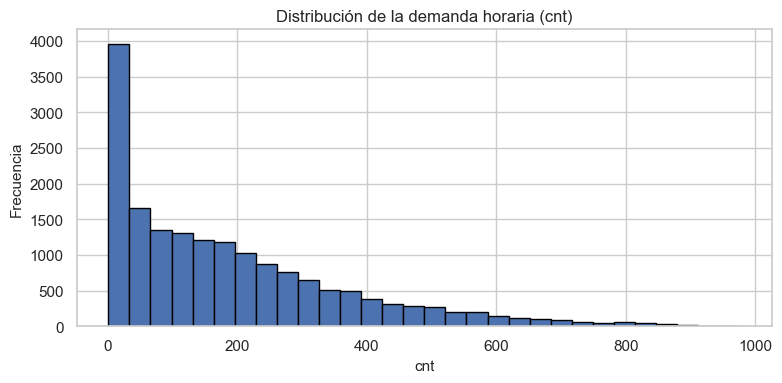

In [9]:
fig, ax = plt.subplots()
ax.hist(df["cnt"], bins=30, edgecolor="black")
ax.set_title("Distribución de la demanda horaria (cnt)")
ax.set_xlabel("cnt")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 3. Variables de uso relacionadas: `casual` y `registered`

Además de `cnt`, el dataset incluye:

- `casual`: usuarios que alquilan bicicletas de manera ocasional.
- `registered`: usuarios registrados en el sistema.

Analizamos su distribución y relación con `cnt`.


In [10]:
df[["casual", "registered"]].describe()

,casual,registered
count,17379.000000,17379.000000
mean,35.676218,153.786869
std,49.305030,151.357286
min,0.000000,0.000000
25%,4.000000,34.000000
50%,17.000000,115.000000
75%,48.000000,220.000000
max,367.000000,886.000000


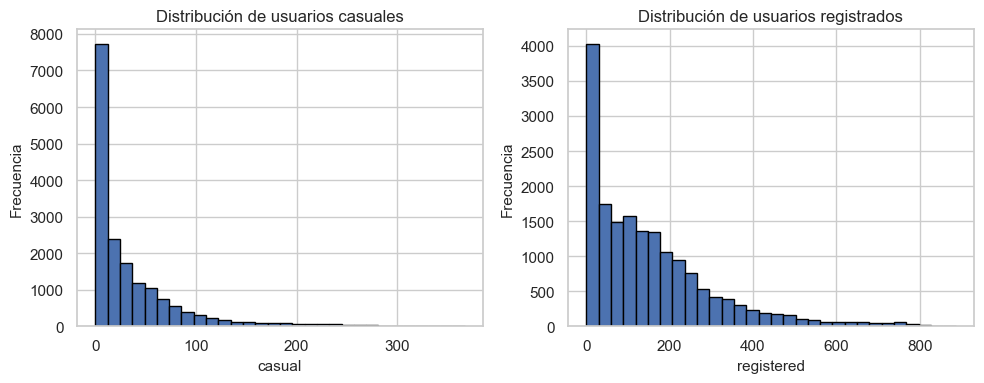

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["casual"], bins=30, edgecolor="black")
axes[0].set_title("Distribución de usuarios casuales")
axes[0].set_xlabel("casual")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(df["registered"], bins=30, edgecolor="black")
axes[1].set_title("Distribución de usuarios registrados")
axes[1].set_xlabel("registered")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [12]:
df[["cnt", "casual", "registered"]].corr()

,cnt,casual,registered
cnt,1.000000,0.694564,0.972151
casual,0.694564,1.000000,0.506618
registered,0.972151,0.506618,1.000000


## 4. Variables ambientales

El dataset incluye variables climáticas normalizadas:

- `temp`: temperatura normalizada.
- `atemp`: sensación térmica normalizada.
- `hum`: humedad relativa.
- `windspeed`: velocidad del viento normalizada.

Analizamos su distribución y posibles relaciones con la demanda `cnt`.


In [13]:
env_vars = ["temp", "atemp", "hum", "windspeed"]
df[env_vars].describe()

,temp,atemp,hum,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098
std,0.192556,0.171850,0.192930,0.122340
min,0.020000,0.000000,0.000000,0.000000
25%,0.340000,0.333300,0.480000,0.104500
50%,0.500000,0.484800,0.630000,0.194000
75%,0.660000,0.621200,0.780000,0.253700
max,1.000000,1.000000,1.000000,0.850700


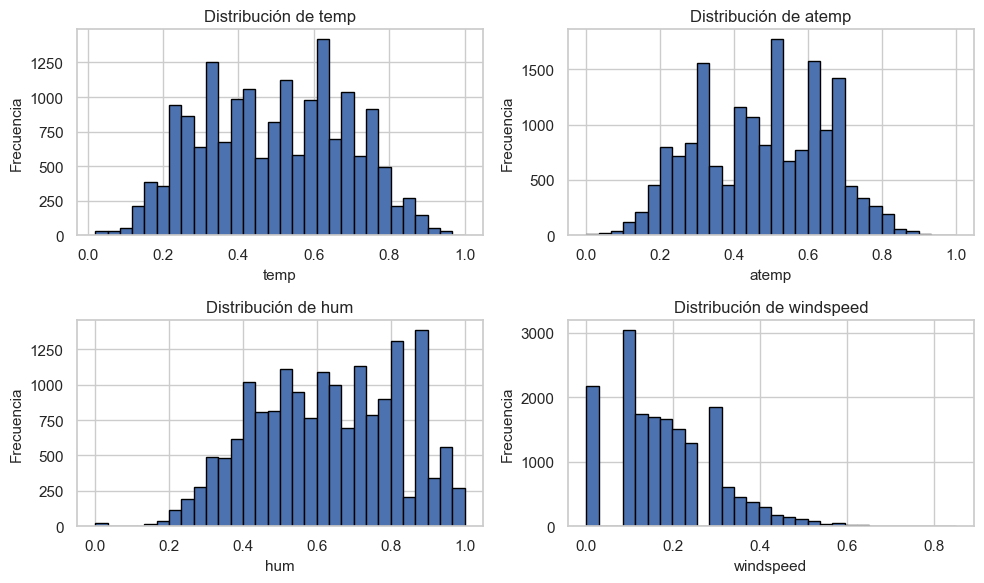

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()
for i, col in enumerate(env_vars):
    axes[i].hist(df[col], bins=30, edgecolor="black")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

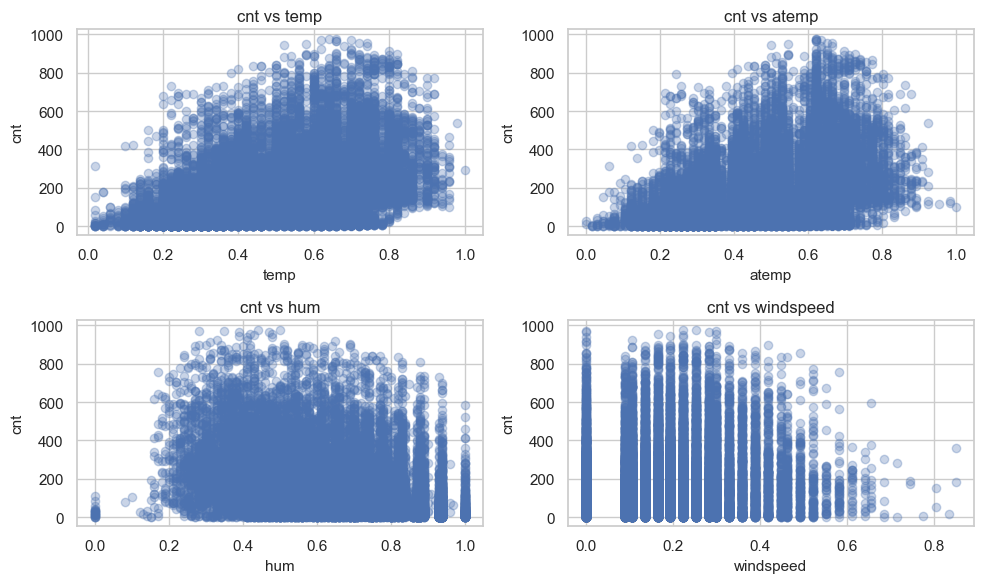

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()
for i, col in enumerate(env_vars):
    axes[i].scatter(df[col], df["cnt"], alpha=0.3)
    axes[i].set_title(f"cnt vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("cnt")
plt.tight_layout()
plt.show()

## 5. Variables temporales

Las variables temporales permiten estudiar patrones por hora, día de la semana,
estación y año:

- `hr`: hora del día (0–23).
- `weekday`: día de la semana.
- `workingday`: indicador de día laboral.
- `season`: estación del año.
- `yr`: año (por ejemplo, 0 = 2011, 1 = 2012).

A continuación, exploramos cómo varía `cnt` a lo largo de estas dimensiones.


C:\Users\User\AppData\Local\Temp\ipykernel_3512\3530942428.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cnt_by_hr = df.groupby("hr")["cnt"].mean()


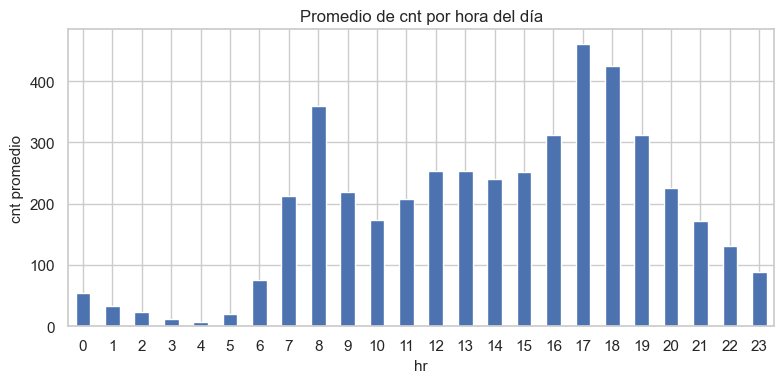

In [16]:
# Promedio de 'cnt' por hora del día
cnt_by_hr = df.groupby("hr")["cnt"].mean()
fig, ax = plt.subplots()
cnt_by_hr.plot(kind="bar", ax=ax)
ax.set_title("Promedio de cnt por hora del día")
ax.set_xlabel("hr")
ax.set_ylabel("cnt promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3512\4159658422.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("workingday")["cnt"].mean().plot(kind="bar", ax=ax)


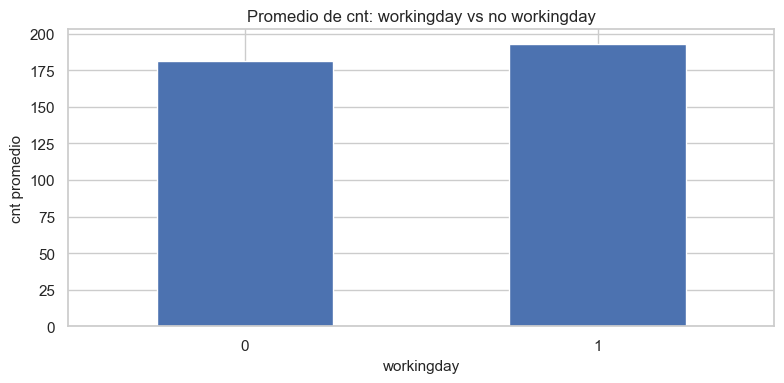

In [17]:
# Promedio de 'cnt' por día laboral vs no laboral
if "workingday" in df.columns:
    fig, ax = plt.subplots()
    df.groupby("workingday")["cnt"].mean().plot(kind="bar", ax=ax)
    ax.set_title("Promedio de cnt: workingday vs no workingday")
    ax.set_xlabel("workingday")
    ax.set_ylabel("cnt promedio")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3512\470849457.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("season")["cnt"].mean().plot(kind="bar", ax=ax)


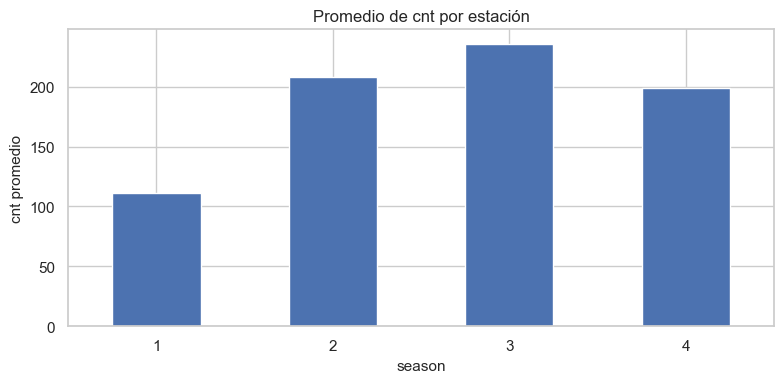

In [18]:
# Promedio de 'cnt' por estación
if "season" in df.columns:
    fig, ax = plt.subplots()
    df.groupby("season")["cnt"].mean().plot(kind="bar", ax=ax)
    ax.set_title("Promedio de cnt por estación")
    ax.set_xlabel("season")
    ax.set_ylabel("cnt promedio")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 6. Matriz de correlación

Calculamos la matriz de correlación para un subconjunto de variables numéricas
de interés, incluyendo la demanda de bicicletas (`cnt`). Esto nos permitirá
identificar relaciones lineales potencialmente útiles para el modelo.


In [20]:
import numpy as np
import pandas as pd

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Si quieres excluir alguna columna numérica específica (como 'instant'):
numeric_cols = [col for col in numeric_cols if col not in ["instant"]]

numeric_cols, len(numeric_cols)

corr = df[numeric_cols].corr()
corr["cnt"].sort_values(ascending=False)



cnt           1.000000
registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400929
windspeed     0.093234
hum          -0.322911
Name: cnt, dtype: float64

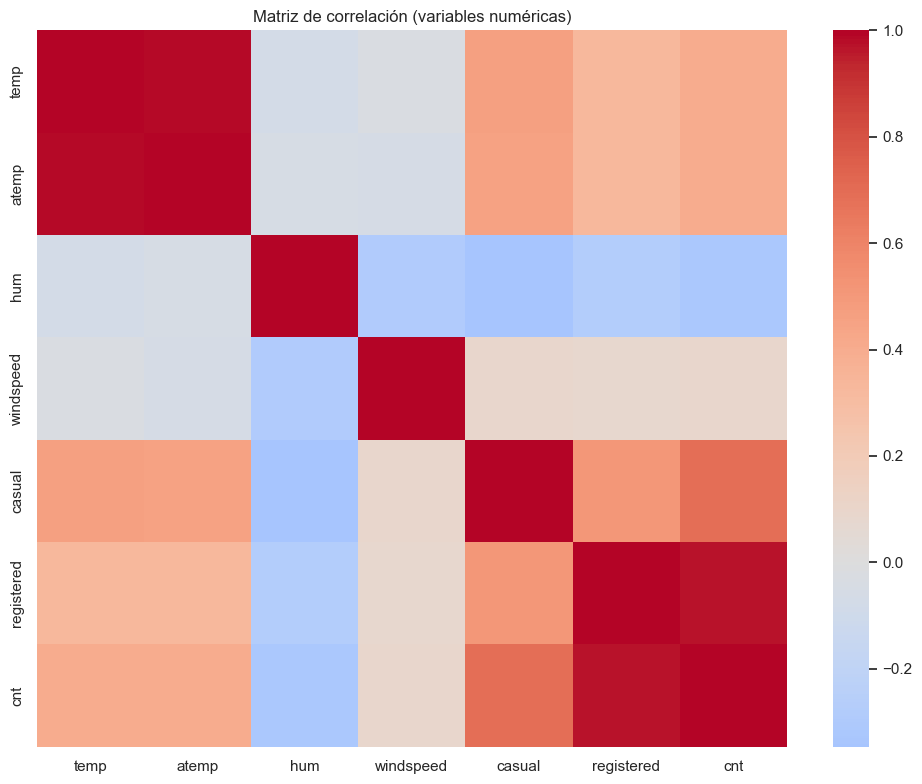

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

## 7. Variables candidatas para el modelo de regresión

A partir del análisis exploratorio, de la interpretación de las variables y de
las correlaciones con `cnt`, una primera selección de **variables candidatas**
para el modelo de regresión lineal múltiple podría incluir:

- Variables de uso:
  - `registered`, `casual` (según el objetivo, podrían ser explicativas o parte
    de otros modelos intermedios).

- Variables ambientales:
  - `temp`, `atemp`, `hum`, `windspeed`.

- Variables temporales y de calendario:
  - `hr`, `weekday`, `workingday`, `season`, `yr`, `weathersit`.

En los siguientes capítulos refinaremos esta selección mediante criterios
estadísticos (correlaciones, multicolinealidad, significancia, validación
cruzada, etc.) y consideraciones de interpretabilidad.


## 8. Conclusión del EDA inicial

En este capítulo:

- Exploramos la estructura del dataset `hour.csv`.
- Analizamos la distribución de la demanda `cnt` y las variables de uso.
- Estudiamos la relación de `cnt` con variables ambientales y temporales.
- Identificamos un conjunto inicial de variables candidatas para el modelo.

En el próximo capítulo abordaremos la **preparación y transformación de datos**,
incluyendo codificación de variables categóricas, posibles transformaciones y
la construcción de matrices de diseño para los modelos de regresión.
